In [ ]:
# Dataset making 

from turtle import speed

import pandas as pd
import numpy as np
np.random.seed(42)

n=100

Temperature = np.random.normal(20, 100, n)
Speed = np.random.uniform(1000,3000,n)
Load = np.random.uniform(10,100,n)
Pressure = np.random.uniform(1,10,n)
Operating_Hours = np.random.uniform(1,20,n)

# Target

Power = (100+0.08*Temperature**2+ 0.02*Speed + 1.5*Load +5*Pressure + 2*Operating_Hours + np.random.normal(0,30,n))

df = pd.DataFrame({'Temperature': Temperature, 'Speed': Speed, 'Load': Load, 'Pressure': Pressure, 'Operating_Hours': Operating_Hours, 'Power': Power})

In [32]:
df

,Temperature,Speed,Load,Pressure,Operating_Hours,Power
0,69.671415,1834.822006,81.533017,4.203754,3.716842,675.934220
1,6.173570,1444.215621,55.237338,7.820615,15.468702,286.239254
2,84.768854,1239.730735,61.921350,1.129541,12.746143,810.175354
3,172.302986,1675.230343,54.326592,2.044654,2.921331,2624.811433
4,-3.415337,2885.819408,27.571869,1.414024,2.598029,180.244919
...,...,...,...,...,...,...
95,-126.351495,1487.979287,76.410723,5.945760,9.905170,1565.380668
96,49.612028,2946.021110,59.891865,4.973775,8.881571,462.029949
97,46.105527,1786.195449,65.054867,8.989338,6.194734,419.215946
98,20.511346,2784.093110,47.764006,4.158235,2.071134,313.703866


In [33]:
df.columns

Index(['Temperature', 'Speed', 'Load', 'Pressure', 'Operating_Hours', 'Power'], dtype='str')

In [34]:
features =['Temperature', 'Speed', 'Load', 'Pressure', 'Operating_Hours']

Identifying linear and curved relationships

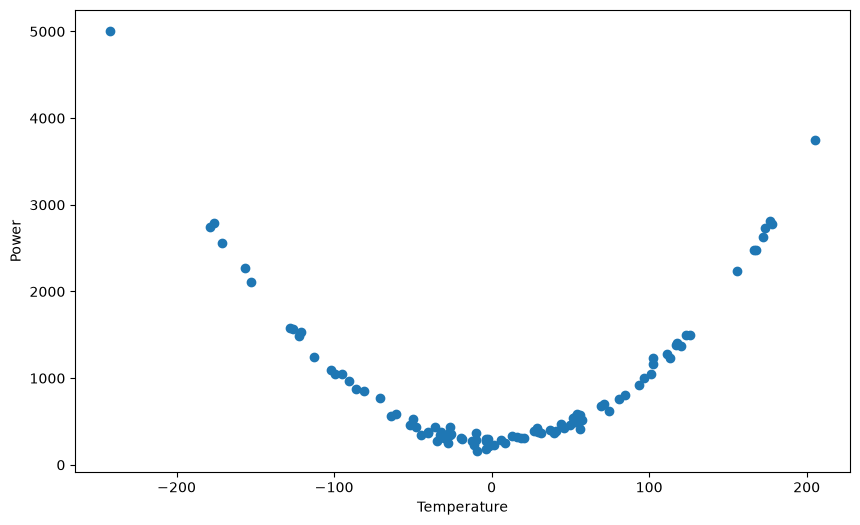

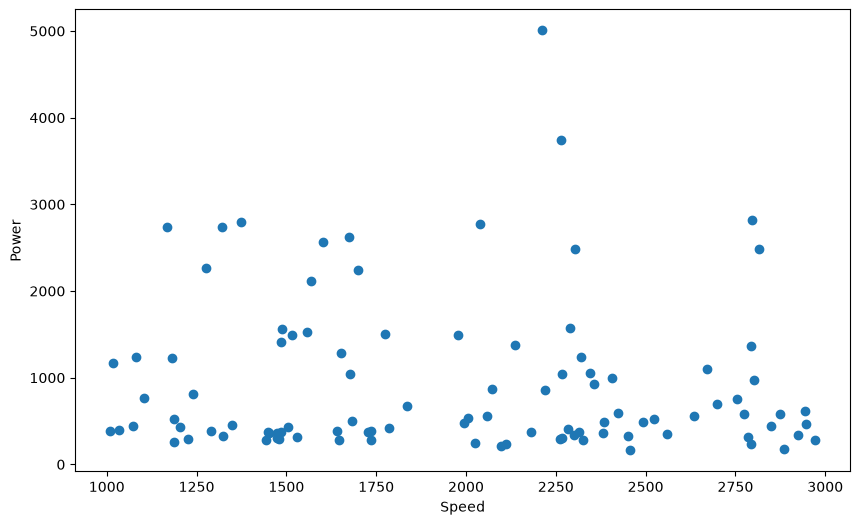

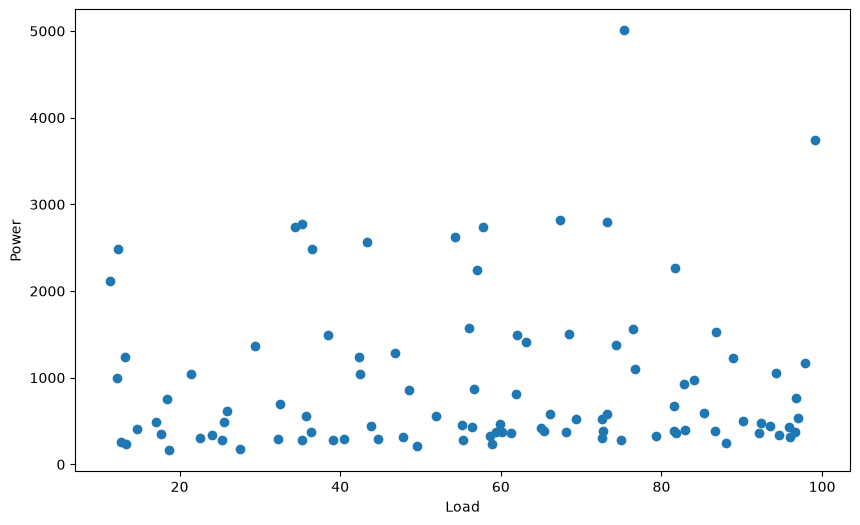

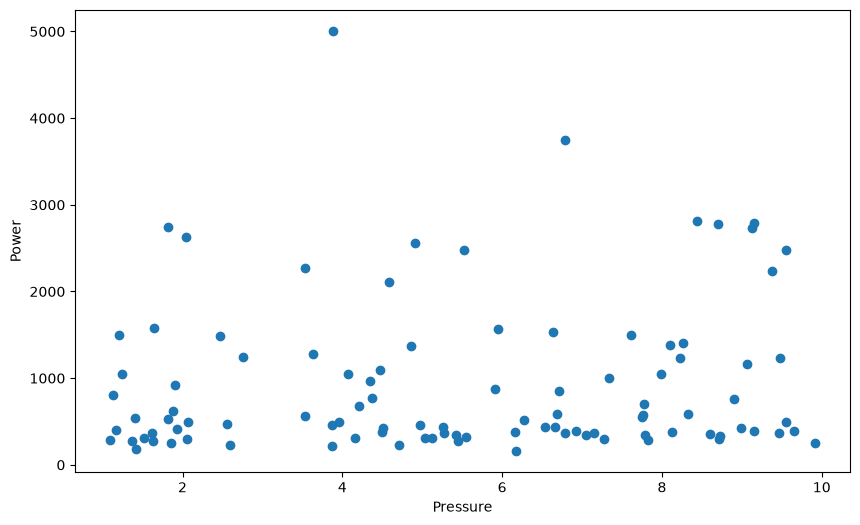

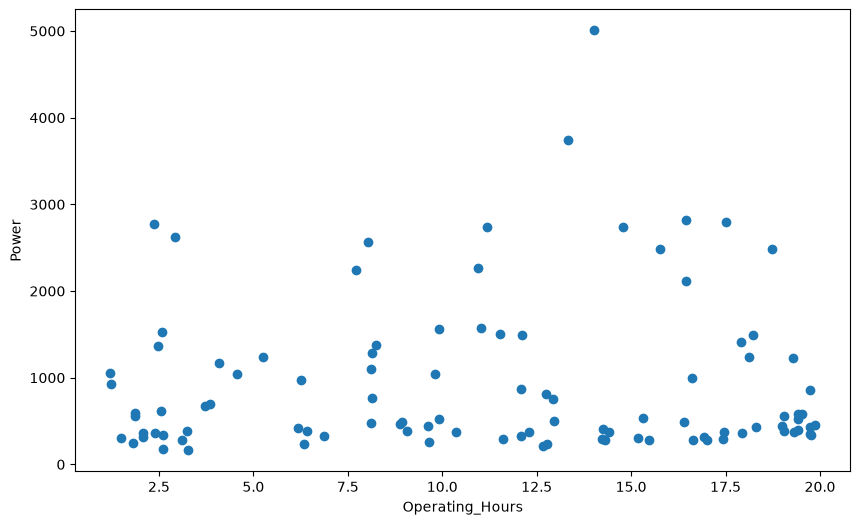

In [35]:
import matplotlib.pyplot as plt
i=0
for col in features:
    plt.figure(figsize=(10,6))
    plt.scatter(df[col],df['Power'])
    plt.xlabel(f'{features[i]}')
    plt.ylabel('Power')
    plt.show
    i+=1

Train/Test Split

In [36]:
X=df.drop('Power',axis=1)
y=df['Power']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
X_train

,Temperature,Speed,Load,Pressure,Operating_Hours
55,113.128012,2319.968092,13.234805,8.231328,18.122002
88,-32.976020,2299.265798,24.079334,7.052666,19.758246
26,-95.099358,2344.271095,94.253930,1.238602,1.215719
42,8.435172,2024.186117,88.036509,1.849987,1.820038
69,-44.511975,2559.751092,17.681272,7.790886,19.738004
...,...,...,...,...,...
60,-27.917424,1186.205536,12.745022,9.914546,9.657478
71,173.803657,1168.279930,57.821917,9.122976,11.185831
14,-152.491783,1569.680989,11.391095,4.586543,16.443192
92,-50.205309,1187.349536,69.417764,1.820855,19.428374


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


Applying multiple linear regression model

In [39]:
lr= LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-0.87,-0.24,-3.48, 5.59,-5.21]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Temperature','Speed','Load','Pressure','Operating_Hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1665
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [40]:
y_pred = lr.predict(X_test)

Predictions

In [41]:
y_pred

array([ 955.08519142,  856.45115651,  957.64912673, 1115.27677815,
        986.9250505 ,  892.66077786, 1025.1252582 ,  950.54923713,
        678.38921696,  888.20027516, 1109.42493281, 1067.40314487,
        572.74929206, 1018.83609261,  862.35523401,  878.69292152,
       1087.19217082,  902.76324671,  802.52983922,  571.56417121])

Evaluating Multiple Regression 

In [42]:
# Mean asolute error
mae=mean_absolute_error(y_test,y_pred)

#Mean squared error
mse=mean_squared_error(y_test,y_pred)

#Root mean squared error
rmse=np.sqrt(mse)

#R2 score
r2=r2_score(y_test,y_pred)

In [43]:
print("MAE",mae)
print("MSE",mse)
print("RMSE",rmse)
print("R2",r2)

MAE 715.3424472990556
MSE 1008744.6988072951
RMSE 1004.3628322510223
R2 -0.2627047582345188


Applying **PolynomialFeatures** to curvved feature(s)

In [44]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2,include_bias=False)
temp_train_poly=poly.fit_transform(X_train[['Temperature']])
temp_test_poly=poly.transform(X_test[['Temperature']])

Combining polynomial & linear features

In [45]:
X_train_poly = np.column_stack([temp_train_poly,X_train[['Temperature', 'Speed', 'Load', 'Pressure', 'Operating_Hours']].values])
X_test_poly = np.column_stack([temp_test_poly,X_test[['Temperature', 'Speed', 'Load', 'Pressure', 'Operating_Hours']].values])

Building polynomial regression model

In [46]:
from sklearn.linear_model import LinearRegression
linReg = LinearRegression()
linReg.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[-0. , 0.08,-0. ,..., 1.36, 4.56, 3.1 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,122.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[98288.71, 5133.06, 1167.88,..., 53.51, 23.56, 0. ]"


Making predictions

In [47]:
y_poly_pred = linReg.predict(X_test_poly)

In [48]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

Evaluating Polynomial Regression 

In [49]:
# Mean asolute error
mae_poly=mean_absolute_error(y_test,y_poly_pred)

#Mean squared error
mse_poly=mean_squared_error(y_test,y_poly_pred)

#Root mean squared error
rmse_poly=np.sqrt(mse_poly)

#R2 score
r2_poly=r2_score(y_test,y_poly_pred)

In [50]:
print("MAE",mae_poly)
print("MSE",mse_poly)
print("RMSE",rmse_poly)
print("R2",r2_poly)

MAE 25.84355603076898
MSE 1102.5527230534374
RMSE 33.20470935053396
R2 0.9986198702493801


Comparing both models

In [51]:
results = pd.DataFrame({
    'Model':['Multiple Regression','Polynomial Regression'],
    'MAE' : [mae,mae_poly],
    'MSE'  : [mse,mse_poly],
    'RMSE' : [rmse,rmse_poly],
    'R2' : [r2,r2_poly]
})

In [52]:
results


,Model,MAE,MSE,RMSE,R2
0,Multiple Regression,715.342447,1.008745e+06,1004.362832,-0.262705
1,Polynomial Regression,25.843556,1.102553e+03,33.204709,0.998620


Analying Residuals

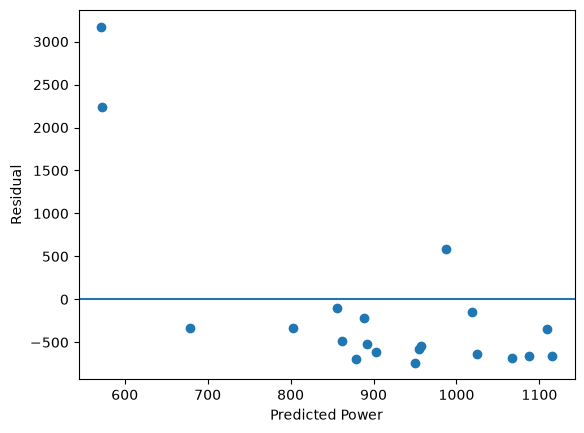

In [53]:
#Linear model
residual_linear = y_test-y_pred
plt.scatter(y_pred,residual_linear)
plt.axhline(y=0) #axis horiontal line
plt.xlabel('Predicted Power')
plt.ylabel('Residual')
plt.show()

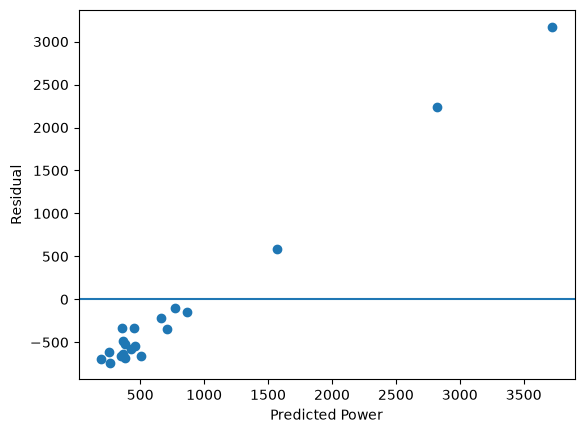

In [54]:
#Polynomial model
residual_polynomial = y_test-y_poly_pred
plt.scatter(y_poly_pred,residual_linear)
plt.axhline(y=0) #axis horiontal line
plt.xlabel('Predicted Power')
plt.ylabel('Residual')
plt.show()

The residual plot of polynomial model is randomly scatterd around zero, so the model is appropriate